In [92]:

from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from chemprop.featurizers.atom import MultiHotAtomFeaturizer
from rdkit.Chem.rdchem import HybridizationType
import pandas as pd
from rdkit import Chem
from chemprop import data, featurizers, models, nn
from ml_enhance import QuantumFPFileLoader

In [93]:
import pandas as pd
from chemprop.data import MoleculeDatapoint, MoleculeDataset
from chemprop.featurizers import SimpleMoleculeMolGraphFeaturizer


def preprocess_to_chemprop_format(
    raw_data: pd.DataFrame, featurizer: SimpleMoleculeMolGraphFeaturizer
) -> MoleculeDataset:
    all_data: list[MoleculeDatapoint] = [
        MoleculeDatapoint.from_smi(smi, [sol], keep_h=True)
        for _, (smi, sol) in raw_data[["smiles", "solubility"]].iterrows()
    ]

    return MoleculeDataset(all_data, featurizer)


df = pd.read_csv("data/processed_dataset.csv")

featurizer = SimpleMoleculeMolGraphFeaturizer()
processed = preprocess_to_chemprop_format(df, featurizer)

In [94]:
split = pd.read_pickle("hpc_splits.pkl")[0][1]
len([processed[i] for i in split])

1753

In [95]:
from torch.utils.data import Subset
ds = Subset(processed, split)

data.build_dataloader(ds, batch_size=10)

In [96]:
split

array([   5,    9,   11, ..., 8741, 8758, 8760], shape=(1753,))

In [97]:
from sklearn.model_selection import KFold

inner_cv = KFold(5, shuffle=True, random_state=99)
list(inner_cv.split(split))[0][1]

array([   2,    3,    6,    9,   14,   15,   16,   18,   22,   25,   28,
         30,   32,   42,   43,   44,   57,   62,   63,   74,   81,   86,
        107,  111,  112,  119,  126,  131,  136,  137,  141,  143,  152,
        156,  158,  160,  163,  167,  168,  172,  174,  182,  191,  201,
        202,  203,  207,  211,  217,  222,  224,  231,  233,  234,  253,
        259,  261,  266,  271,  273,  282,  285,  292,  304,  307,  310,
        313,  317,  333,  336,  342,  350,  351,  356,  360,  376,  382,
        383,  385,  389,  390,  391,  392,  396,  405,  407,  411,  412,
        416,  418,  442,  456,  461,  464,  468,  478,  481,  482,  487,
        491,  500,  504,  509,  519,  522,  523,  524,  538,  541,  547,
        548,  561,  562,  564,  565,  569,  576,  581,  583,  587,  594,
        596,  597,  600,  615,  616,  628,  636,  644,  645,  648,  649,
        654,  655,  664,  666,  671,  679,  680,  685,  686,  693,  700,
        704,  718,  719,  721,  722,  730,  738,  7

In [98]:
loader = QuantumFPFileLoader("data/QuantumFP/QFP_output")
filelist = loader.list_output_files()
for df in loader.stream_conformer_dataframe(filelist[0]):
    tdf = df

In [99]:
tdf["original_smiles"].values

<StringArray>
['[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23']
Length: 1, dtype: string

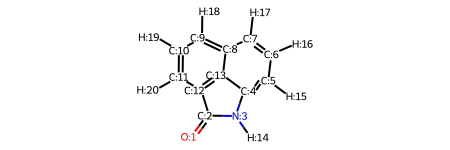

In [100]:
Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False)

In [101]:
for atom in Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False).GetAtoms():
    print(atom.GetAtomMapNum())

1
2
3
14
4
5
15
6
16
7
17
8
9
18
10
19
11
20
12
13


In [102]:
import numpy as np

dips = [dip[1] for dip in tdf["atomic_dipole"][0]]
np.array(dips).sum(axis=0)

array([-9.72435218e-02, -1.85325173e-01,  8.11703750e-07])

In [103]:
tdf["molecular_dipole"][0]

[-1.5076436182670554, -0.13841485683182708, 1.1795803790465398e-06]

In [104]:
tdf["atomic_charge_dipole_interaction"].to_numpy()

array([list([[1, 2, 0.0033359316094680835], [1, 3, -0.00022245634665863908], [1, 4, -0.005489815938149715], [1, 5, 8.532834909950155e-05], [1, 6, -0.00046551375264068694], [1, 7, -0.0003613352452160964], [1, 8, 0.00017165466008306333], [1, 9, -0.0002038406978157412], [1, 10, -0.0007695176822570202], [1, 11, 0.0008947084902147923], [1, 12, -0.004802244330944193], [1, 13, -0.00029005914614982473], [1, 14, 0.004214639729920416], [1, 15, 0.001189323609975297], [1, 16, 0.0011940645064860552], [1, 17, 0.0012293819223028993], [1, 18, 0.0014993020387240703], [1, 19, 0.0015671014044818313], [1, 20, 0.0007703595383967832], [2, 1, 0.03578395325359559], [2, 3, 0.0021648156401432184], [2, 4, 0.007935216890220349], [2, 5, -6.56953249425921e-05], [2, 6, 0.000490255693567733], [2, 7, 0.00038585728343693183], [2, 8, -0.00021292260398937486], [2, 9, 0.0002724631673193278], [2, 10, 0.0007386117298645389], [2, 11, -0.0008021877051539738], [2, 12, 0.009777806550568919], [2, 13, 0.0005466456771364342], [2, 

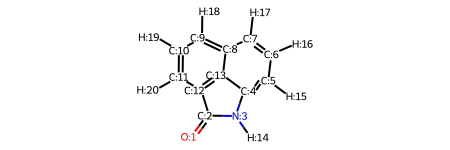

In [105]:
all_data[0].mol

In [106]:
for atom in all_data[0].mol.GetAtoms():
    print(atom.GetAtomMapNum())

1
2
3
14
4
5
15
6
16
7
17
8
9
18
10
19
11
20
12
13


In [107]:
atomic_nums = list(range(1, 37)) + [53] # Look up which atomic numbers occur in the dataset
degrees = [0, 1, 2, 3, 4, 5]
formal_charges = []
chiral_tags = [0, 1, 2, 3]
num_Hs = [0, 1, 2, 3, 4]
hybridizations = [HybridizationType.S, HybridizationType.SP, HybridizationType.SP2, HybridizationType.SP2D, HybridizationType.SP3, HybridizationType.SP3D, HybridizationType.SP3D2]
featurizer = MultiHotAtomFeaturizer(
    atomic_nums, degrees, formal_charges, chiral_tags, num_Hs, hybridizations
)
featurizer(atom_to_featurize)

NameError: name 'atom_to_featurize' is not defined

In [108]:
df = pd.read_csv(r"data\processed_dataset.csv")[:1000]

In [109]:
from chemprop.models import MPNN
from chemprop.nn import BondMessagePassing, Aggregation, RegressionFFN
# from chemprop.nn.metrics import MSEMetric

In [110]:
def build_model():
    mp = BondMessagePassing(
        d_h=300,
        depth=3
    )

    agg = Aggregation(
        method="mean" # should be norm or something else as solubility is extensive (dependent on size)
    )

    ffn = RegressionFFN(
        input_dim=300,
        hidden_dim=300,
        n_layers=1,
        output_dim=1,
        dropout=0.1
    )

    return MPNN(mp, agg, ffn)

In [111]:
all_data = [data.MoleculeDatapoint.from_smi(smi, [sol], keep_h=True) for _, (smi, sol) in df[["smiles", "solubility"]].iterrows()]

In [112]:
mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits

train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_indices

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


[[np.int64(859),
  np.int64(298),
  np.int64(553),
  np.int64(672),
  np.int64(971),
  np.int64(27),
  np.int64(231),
  np.int64(306),
  np.int64(706),
  np.int64(496),
  np.int64(558),
  np.int64(784),
  np.int64(239),
  np.int64(578),
  np.int64(55),
  np.int64(906),
  np.int64(175),
  np.int64(14),
  np.int64(77),
  np.int64(31),
  np.int64(481),
  np.int64(310),
  np.int64(311),
  np.int64(883),
  np.int64(788),
  np.int64(45),
  np.int64(103),
  np.int64(760),
  np.int64(1),
  np.int64(823),
  np.int64(710),
  np.int64(614),
  np.int64(790),
  np.int64(408),
  np.int64(736),
  np.int64(957),
  np.int64(366),
  np.int64(918),
  np.int64(267),
  np.int64(230),
  np.int64(996),
  np.int64(635),
  np.int64(698),
  np.int64(251),
  np.int64(783),
  np.int64(819),
  np.int64(141),
  np.int64(316),
  np.int64(587),
  np.int64(331),
  np.int64(295),
  np.int64(262),
  np.int64(432),
  np.int64(862),
  np.int64(582),
  np.int64(272),
  np.int64(270),
  np.int64(987),
  np.int64(319),
  np.

In [113]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

In [ ]:
splits = pd.read_pickle("hpc_splits.pkl")
for idx, split in enumerate(splits):
    print(idx)
    train_idxs, test_idxs = split
    train_idxs = train_idxs.reshape(1, -1)
    test_idxs = test_idxs.reshape(1, -1)

    train_data, _, test_data = data.split_data_by_indices(
        data=all_data, train_indices=train_idxs, test_indices=test_indices
    )

    print(type(train_data[0][0]))
    print(np.array(train_data[0])[[1, 2, 3]])

    test_dset = data.MoleculeDataset(test_data[0], featurizer)

    best_params = run_tuning_per_fold(...)


    train_dset = data.MoleculeDataset(train_data[0], featurizer)
    scaler = train_dset.normalize_targets()


    break

0


IndexError: list index out of range

In [114]:
train_data, val_data, test_data = data.split_data_by_indices(
    all_data, train_indices, val_indices, test_indices
)

In [115]:


train_dset = data.MoleculeDataset(train_data[0], featurizer)
scaler = train_dset.normalize_targets()

# train_dset._X_d


val_dset = data.MoleculeDataset(val_data[0], featurizer)
val_dset.normalize_targets(scaler)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

In [116]:
num_workers = 1
train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

In [117]:
len(val_loader)

2

In [ ]:
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
ffn = nn.RegressionFFN()

batch_norm = True
metric_list = [nn.metrics.MSE(), nn.metrics.R2Score()]

mpnn = models.MPNN(mp, agg, ffn, batch_norm=True, metrics=metric_list)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): Identity()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): RMSE(task_weights=[[1.0]])
    (1): R2Score()
    (2): MSE

In [134]:
class DebugCallback(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        print("Callback metrics:", trainer.callback_metrics)

In [135]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)


trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=5, # number of epochs to train for
    callbacks=[DebugCallback()], # Use the configured checkpoint callback
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [136]:
trainer.callback_metrics

{}

In [137]:
trainer.fit(mpnn, train_loader, val_loader)

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


In [143]:
trainer.callback_metrics

{'test/rmse': tensor(0.6579), 'test/r2': tensor(0.5721)}

In [141]:
test = trainer.test(mpnn, val_loader, weights_only=False)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test/r2          │    0.5721385478973389     │
│         test/rmse         │    0.6579418778419495     │
└───────────────────────────┴───────────────────────────┘

In [142]:
test[0]

{'test/rmse': 0.6579418778419495, 'test/r2': 0.5721385478973389}

In [146]:
from dataclasses import dataclass, field, asdict
import torch

@dataclass
class FixedParams:
    use_gpu: bool = torch.cuda.is_available()
    batch_size: int = 100
    num_workers: int = 1
    dropout: float = 0.1
    n_epochs: int = 30
    metrics: list = field(default_factory=lambda: [nn.metrics.MSE(), nn.metrics.R2Score()])
    opt_n_trials: int = 30
    opt_direction: str = "minimize"

asdict(FixedParams())

{'use_gpu': False,
 'batch_size': 100,
 'num_workers': 1,
 'dropout': 0.1,
 'n_epochs': 30,
 'metrics': [MSE(task_weights=[[1.0]]), R2Score()],
 'opt_n_trials': 30,
 'opt_direction': 'minimize'}

In [150]:
import pickle

dataset = pd.read_pickle("data/chemprop_dataset1.pkl")

dataset[0].mg

MolGraph(V=array([[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.14007],
       ...,
       [1.     , 0.     , 0.     , ..., 0.     , 0.     , 0.01008],
       [0.     , 0.     , 0.     , ..., 0.     , 1.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 1.     , 0.12011]],
      shape=(20, 72), dtype=float32), E=array([[0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [